check versioning

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.2.0+cu121
CUDA version: 12.1


In [2]:
from pathlib import Path
import json

annotation_dir = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\\D1_2\\annotations\\SMOOTHED")

annotations_train_m1_path = annotation_dir / "instances_train_smooth_m1.json"
annotations_val_m1_path = annotation_dir / "instances_val_smooth_m1.json"

with open (annotations_train_m1_path, mode="r") as f:
    annotations_train_m1 = json.load(f)

with open (annotations_val_m1_path, mode="r") as f:
    annotations_val_m1 = json.load(f)

print(len(annotations_train_m1["categories"]))
print(annotations_train_m1["categories"])
print(len(annotations_val_m1["categories"]))
print(annotations_val_m1["categories"])

21
[{'id': 1000, 'name': 'Facade', 'supercategory': 'object'}, {'id': 0, 'name': '0', 'supercategory': 'object'}, {'id': 1, 'name': '1', 'supercategory': 'object'}, {'id': 2, 'name': '2', 'supercategory': 'object'}, {'id': 3, 'name': '3', 'supercategory': 'object'}, {'id': 4, 'name': '4', 'supercategory': 'object'}, {'id': 5, 'name': '5', 'supercategory': 'object'}, {'id': 6, 'name': '6', 'supercategory': 'object'}, {'id': 7, 'name': '7', 'supercategory': 'object'}, {'id': 8, 'name': '8', 'supercategory': 'object'}, {'id': 9, 'name': '9', 'supercategory': 'object'}, {'id': 10, 'name': '10', 'supercategory': 'object'}, {'id': 11, 'name': '11', 'supercategory': 'object'}, {'id': 12, 'name': '12', 'supercategory': 'object'}, {'id': 13, 'name': '13', 'supercategory': 'object'}, {'id': 14, 'name': '14', 'supercategory': 'object'}, {'id': 15, 'name': '15', 'supercategory': 'object'}, {'id': 16, 'name': '16', 'supercategory': 'object'}, {'id': 17, 'name': '17', 'supercategory': 'object'}, {'i

In [6]:
!pip install "setuptools<70.0.0"

   ---------------------------------------- 0.0/894.6 kB ? eta -:--:--
   ---------------------------------------- 894.6/894.6 kB 6.7 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1


In [3]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random


# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

In [4]:
from detectron2.data import DatasetCatalog, MetadataCatalog


datasets_to_remove = ["E1_M1_dataset_train", "E1_M1_dataset_val"]

for dataset_name in datasets_to_remove:
    if dataset_name in DatasetCatalog:
        del DatasetCatalog[dataset_name]


    if dataset_name in MetadataCatalog:
        del MetadataCatalog[dataset_name]

print("ok")

ok


In [5]:
from detectron2.data.datasets import register_coco_instances

IMAGES_DIR = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\D1_2\\images")
train_images_dir = IMAGES_DIR / "train"
val_images_dir = IMAGES_DIR / "val"

register_coco_instances("E1_M1_dataset_train", {}, annotations_train_m1_path, train_images_dir)
register_coco_instances("E1_M1_dataset_val", {}, annotations_val_m1_path, val_images_dir)

WARNING [06/06 16:42:13 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[06/06 16:42:13 d2.data.datasets.coco]: Loaded 334 images in COCO format from C:\Users\WA\Desktop\badanie\syncity3D\COCO_DATASETS\D1_2\annotations\SMOOTHED\instances_train_smooth_m1.json


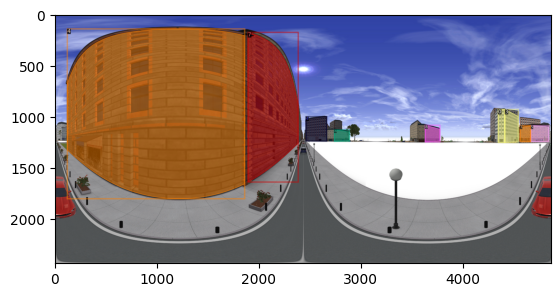

In [ ]:
import random
import cv2
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import Visualizer
import matplotlib.pyplot as plt

dataset_name = "E1_M1_dataset_train"

# registry dicts build by detectron
my_metadata = MetadataCatalog.get(dataset_name)
dataset_dicts = DatasetCatalog.get(dataset_name)


for d in random.sample(dataset_dicts, min(3, len(dataset_dicts))):
    img = cv2.imread(d["file_name"])

    visualizer = Visualizer(img[:, :, ::-1], metadata=my_metadata, scale=0.8)

    out = visualizer.draw_dataset_dict(d)

    plt.imshow(out.get_image()[:, :, :])

In [11]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# dla testu
cfg.DATASETS.TRAIN = ("E1_M1_dataset_val")
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 12  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 300    # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.SOLVER.STEPS = []        # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(annotations_train_m1["categories"])  #. (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.
cfg.INPUT.MASK_FORMAT = "bitmask"


cfg.OUTPUT_DIR = "C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\EKSPERYMENT\\E2_jakis\\output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()

[06/06 17:00:21 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (22, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (22,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (84, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (84,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (21, 256, 1, 

[06/06 17:00:21 d2.engine.train_loop]: Starting training from iteration 0
[06/06 17:43:39 d2.utils.events]:  eta: 10:08:38  iter: 19  total_loss: 6.508  loss_cls: 3.05  loss_box_reg: 0.309  loss_mask: 0.6909  loss_rpn_cls: 2.032  loss_rpn_loc: 0.359    time: 129.6507  last_time: 133.7414  data_time: 4.0187  last_data_time: 3.4260   lr: 1.6068e-05  max_mem: 12841M
[06/06 18:29:11 d2.utils.events]:  eta: 9:42:06  iter: 39  total_loss: 4.891  loss_cls: 2.7  loss_box_reg: 0.5659  loss_mask: 0.6844  loss_rpn_cls: 0.694  loss_rpn_loc: 0.2956    time: 133.3194  last_time: 138.0895  data_time: 3.6569  last_data_time: 3.7408   lr: 3.2718e-05  max_mem: 12841M
[06/06 19:14:22 d2.utils.events]:  eta: 8:59:06  iter: 59  total_loss: 3.828  loss_cls: 2.044  loss_box_reg: 0.7364  loss_mask: 0.6722  loss_rpn_cls: 0.164  loss_rpn_loc: 0.2371    time: 134.0780  last_time: 132.3749  data_time: 3.8785  last_data_time: 3.6308   lr: 4.9367e-05  max_mem: 12841M
[06/06 19:58:56 d2.utils.events]:  eta: 8:13:17 

In [1]:
# Inference should use the config with parameters that are used in training
# cfg now already contains everything we've set previously. We changed it a little bit for inference:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.25   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

NameError: name 'os' is not defined

In [ ]:
from detectron2.utils.visualizer import ColorMode


dataset_name = "E1_M1_dataset_train"

# registry dicts build by detectron
my_metadata = MetadataCatalog.get(dataset_name)
dataset_dicts = DatasetCatalog.get(dataset_name)


for d in random.sample(dataset_dicts, 3):    
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
    v = Visualizer(im[:, :, ::-1],
                   metadata=my_metadata, 
                   scale=0.5, 
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.imshow(out.get_image()[:, :, :])

WARNING [06/07 20:44:26 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[06/07 20:44:26 d2.data.datasets.coco]: Loaded 334 images in COCO format from C:\Users\WA\Desktop\badanie\syncity3D\COCO_DATASETS\D1_2\annotations\SMOOTHED\instances_train_smooth_m1.json
